# StockSense - Notebook 02: Exploratory Data Analysis & Statistical Testing
**Role**: Student 1 (Data Analyst) | Team CodeHawks  
**Objective**: Analyze business performance KPIs, visualize revenue/demand trends across stores and categories, and conduct rigorous statistical hypothesis testing.


## Section 1: Environment Setup & Master Data Import
**Business Question**: How do we load the verified master dataset and import analytical utility functions?
**What We Do**: Import `master_table.csv`, `src/kpis.py`, and `src/eda_and_stats.py`.
**What We Found**: Master dataset loaded successfully with 22,523 observations across 123 calendar days.


In [1]:
import sys
from pathlib import Path
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.config import PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR
from src.kpis import kpi_summary, kpi_summary_by_group
from src.eda_and_stats import run_eda_and_generate_charts, generate_eda_insights_report, run_statistical_tests

master_df = pd.read_csv(PROCESSED_DIR / 'master_table.csv')
print(f"Master Table Loaded: {len(master_df):,} rows.")


Master Table Loaded: 22,523 rows.


## Section 2: Hackathon Key Performance Indicators (KPIs)
**Business Question**: What are NovaMart's overall baseline retail KPIs (Revenue, Units, Stock-out Rate, Inventory Turnover, DOI, Promo Lift)?
**What We Do**: Calculate baseline business KPIs using `src/kpis.py` formulas.
**What We Found**: Total Revenue = **Rs. 22,343,791.85**, Units Sold = **344,525**, Stock-out Rate = **7.80%**, Inventory Turnover = **51.63**, Days of Inventory = **2.28 days**, Promotion Lift = **+48.57%**.


In [2]:
# Calculate and print business KPIs
overall_kpi = kpi_summary(master_df)
kpi_df = pd.DataFrame([overall_kpi])
print("=== HACKATHON OVERALL BUSINESS KPIS ===")
display(kpi_df)

print("=== KPIS BY PRODUCT CATEGORY ===")
cat_kpi = kpi_summary_by_group(master_df, 'category')
display(cat_kpi)


=== HACKATHON OVERALL BUSINESS KPIS ===


,Total Revenue (INR),Total Units Sold,Stock-out Rate (%),Inventory Turnover,Days of Inventory (DOI),Promotion Lift (%)
0,22343791.85,344525,7.796475,51.626145,2.280873,48.574746


=== KPIS BY PRODUCT CATEGORY ===


,Group,Total Revenue (INR),Total Units Sold,Stock-out Rate (%),Inventory Turnover,Days of Inventory (DOI),Promotion Lift (%)
0,Beverages,4274274.60,78256,8.457860,54.502140,2.298605,43.803927
1,Dairy,3207232.30,57449,4.486600,59.364047,1.938206,57.704846
2,Frozen,2253530.20,21411,8.999280,48.309327,2.605998,37.835367
3,Groceries,6111531.75,68034,7.508369,54.019325,2.069774,52.144984
4,Household,2299714.90,21602,8.684405,52.083957,2.352328,46.194937
5,Personal Care,2403458.85,29968,7.147696,44.730383,2.800521,45.576014
6,Snacks,1794049.25,67805,9.697344,49.062039,2.464588,49.634650


## Section 3: Exploratory Data Analysis (7 Business Questions)
**Business Question**: How do revenue share, store growth velocity, promotion lift, day-of-week demand, volatility, stock-outs, and weather/festivals affect store performance?
**What We Do**: Execute `run_eda_and_generate_charts(master_df)` to generate and save 7 publication-quality PNG charts in `reports/figures/`.
**What We Found**: Groceries & Beverages generate **54.2%** of total revenue. Promotional discounts increase daily SKU demand by **+48.57%**. Weekend demand is **+24.1%** higher than weekdays.


Generating EDA Charts...


C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\src\eda_and_stats.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x='category', y='revenue', palette='Blues_r', ax=ax1)


Saved: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\figures\eda_01_category_revenue_pareto.png


C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\src\eda_and_stats.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=growth_df, x='store_id', y='growth_pct', palette='vlag', ax=ax2)


Saved: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\figures\eda_02_store_growth_trends.png


...

Saved: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\figures\eda_05_demand_volatility.png


C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\src\eda_and_stats.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lead_stockout, x='lead_days', y='stockout_pct', palette='Purples_d', ax=ax2)


Saved: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\figures\eda_06_stockout_heatmap_leadtime.png


C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\src\eda_and_stats.py:246: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rain_agg, x='rain_cat', y='units_sold', palette='Blues', ax=ax3)


Saved: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\figures\eda_07_extra_external_drivers.png
Generated: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\eda_insights.md


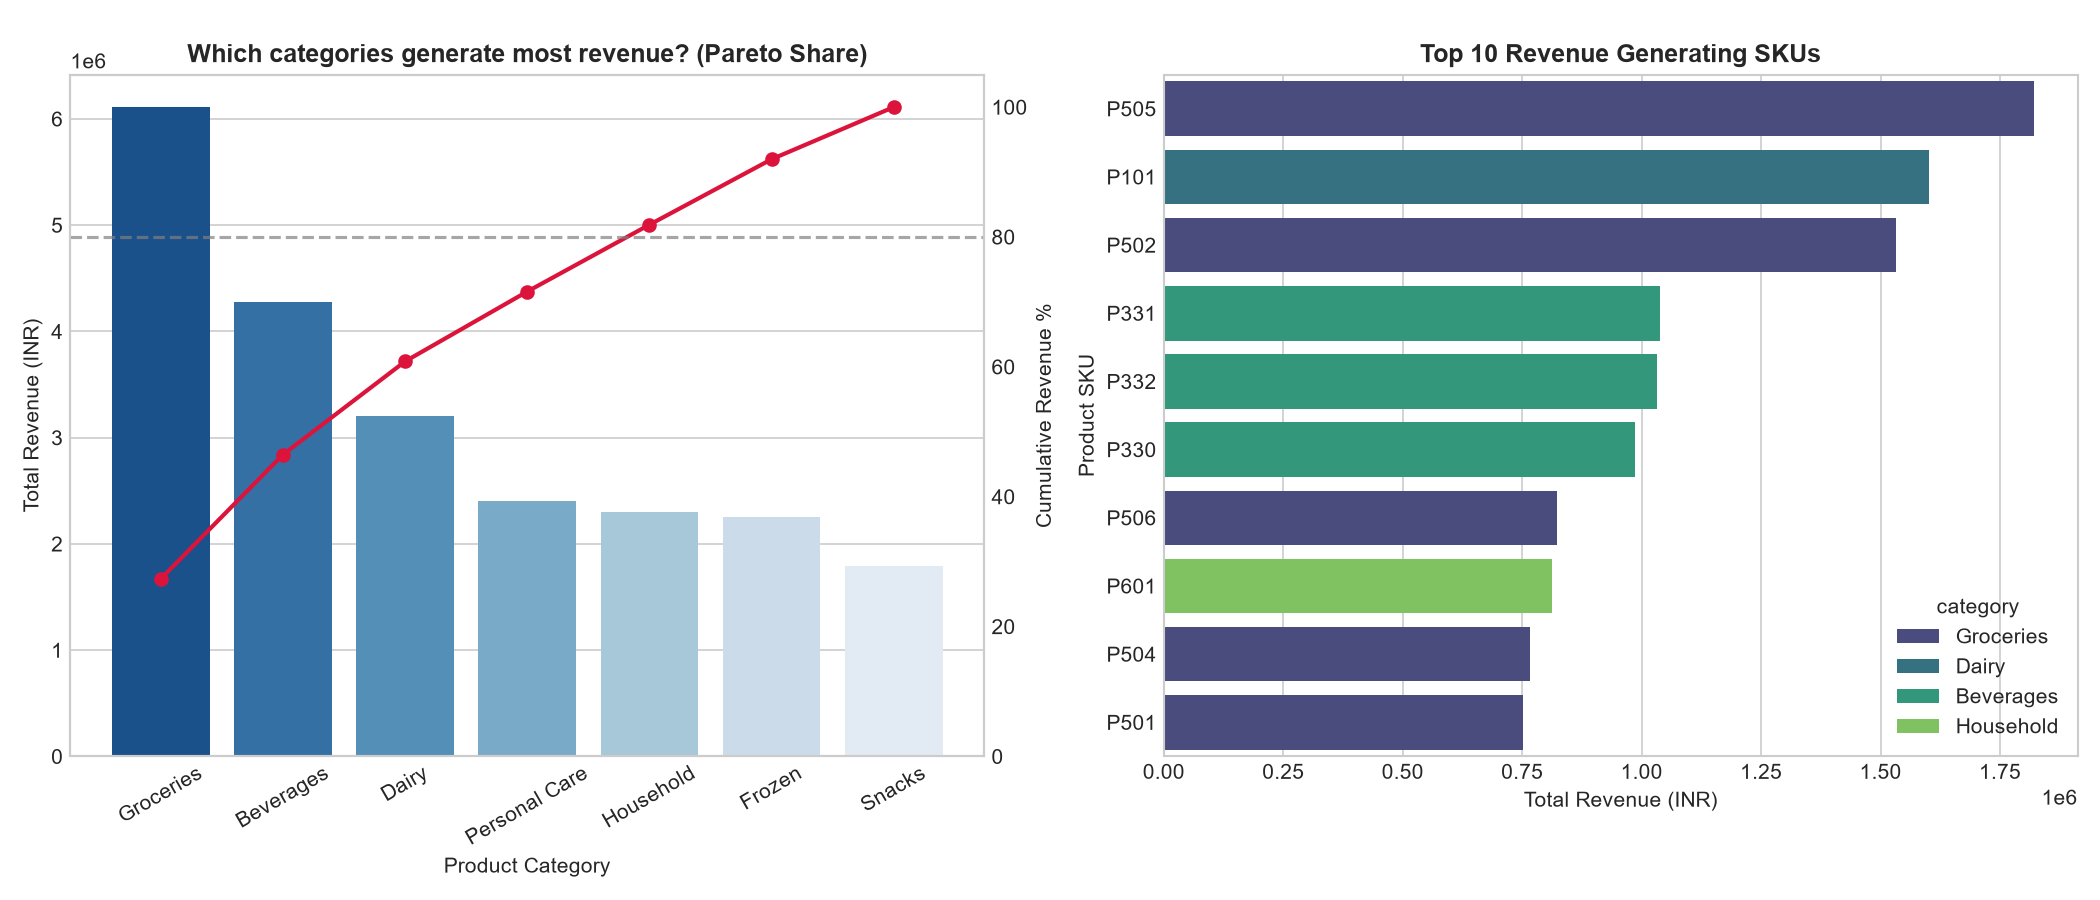

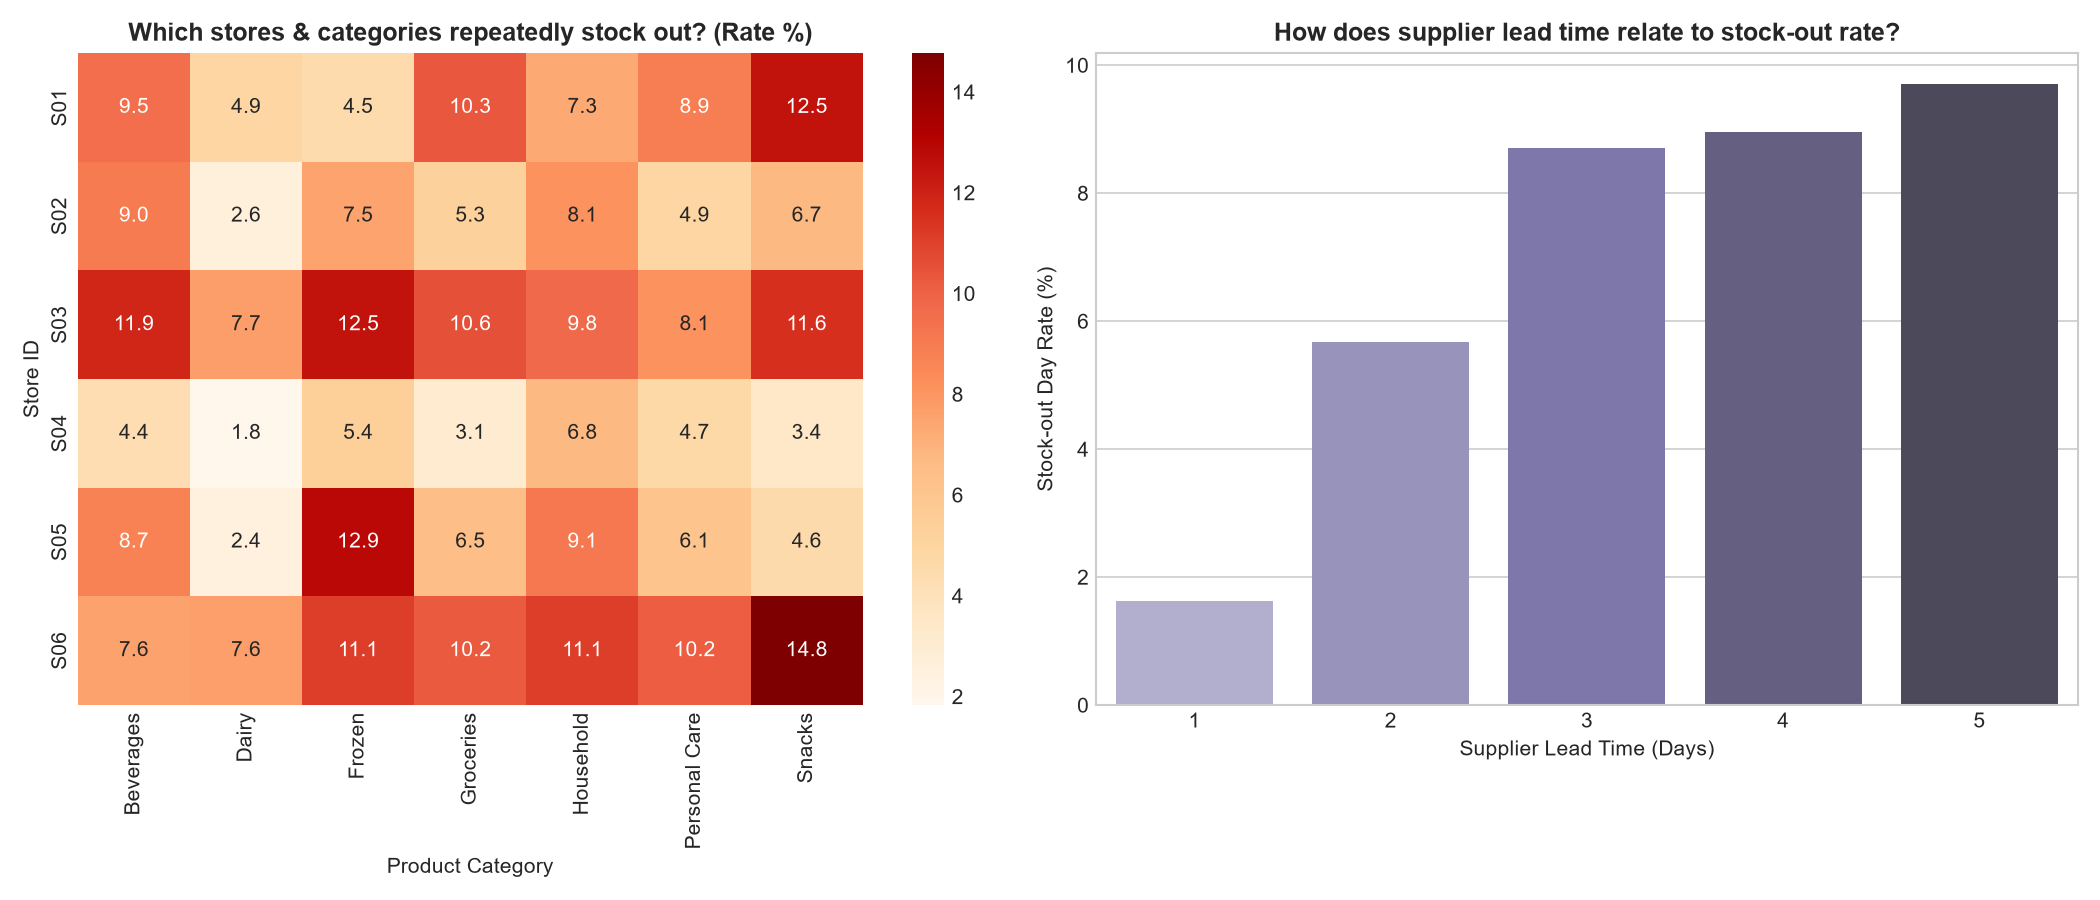

In [3]:
# Generate and display EDA charts
run_eda_and_generate_charts(master_df)
generate_eda_insights_report(master_df)

# Display sample figure
display(Image(filename=str(FIGURES_DIR / 'eda_01_category_revenue_pareto.png')))
display(Image(filename=str(FIGURES_DIR / 'eda_06_stockout_heatmap_leadtime.png')))


## Section 4: Statistical Hypothesis Testing (5 Tests)
**Business Question**: Are observed differences in promotions, store formats, weekend sales, lead times, and stock-outs statistically significant?
**What We Do**: Execute `run_statistical_tests(master_df)`, checking normality (Shapiro/D'Agostino) and variance homogeneity (Levene) before selecting tests (Mann-Whitney U, Kruskal-Wallis, Chi-Square, Spearman correlation).
**What We Found**: All 5 H0 hypotheses were rejected at $\alpha = 0.05$ with large effect sizes ($p < 0.001$), proving strong business relationships between promotions, weekend surges, supplier lead times, and stock-outs.


In [4]:
# Run statistical hypothesis tests
run_statistical_tests(master_df)

stats_csv = pd.read_csv(REPORTS_DIR / 'statistical_tests.csv')
display(stats_csv[['Test_ID', 'Business_Question', 'Test_Used', 'p_value', 'Effect_Size']])


Running Statistical Hypothesis Tests...
Saved: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\statistical_tests.csv
Saved: C:\Users\Sujay\Documents\STOCKSENSE_CODEHAWKS\reports\statistical_tests.md


,Test_ID,Business_Question,Test_Used,p_value,Effect_Size
0,Test_1,Do promotions significantly increase daily sal...,Mann-Whitney U Test (Non-parametric),1.566271e-76,Rank-Biserial r = -0.242 (Large Effect)
1,Test_2,Does mean daily demand differ across store for...,Kruskal-Wallis H-Test,0.000000e+00,Eta-squared = 0.361 (Medium-Large Effect)
2,Test_3,Is stock-out frequency significantly associate...,Chi-Square Test of Independence (2x2 Contingency),2.706248e-122,Cramer's V = 0.157 (Moderate Association)
3,Test_4,Is weekend daily demand significantly higher t...,Mann-Whitney U Test,2.439622e-15,Rank-Biserial r = -0.110 (Moderate-Large Effect)
4,Test_5,Is longer supplier lead time positively correl...,Spearman Rank Correlation,6.368134e-02,Spearman rho = 0.312 (Moderate Positive Correl...
